In [1]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
BASE_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print("Train:", TRAIN_DIR.resolve())
print("Val  :", VAL_DIR.resolve())
print("Test :", TEST_DIR.resolve())

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation folder not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

Train: D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\train
Val  : D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\val
Test : D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\test


In [5]:
train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes   = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])
test_classes  = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", train_classes)
print("Val classes:  ", val_classes)
print("Test classes: ", test_classes)

assert train_classes == val_classes == test_classes, "Class folders are inconsistent."

CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)

print("\nNumber of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Train classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Val classes:   ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Test classes:  ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']

Number of classes: 8
Classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [6]:
def count_images(split_dir):
    counts = {}
    valid_ext = {".jpg", ".png"}
    
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = sum(
                1 for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in valid_ext
            )
    return pd.Series(counts, name=split_dir.name)

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

distribution = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)

display(distribution)

,train,val,test
AMD,1000,41,41
Cataract,1200,51,51
Diabetic_Retinopathy,2879,617,617
Glaucoma,1500,139,140
Hypertension,700,13,13
Myopia,1000,44,44
Normal,3288,705,705
Others,1500,166,165


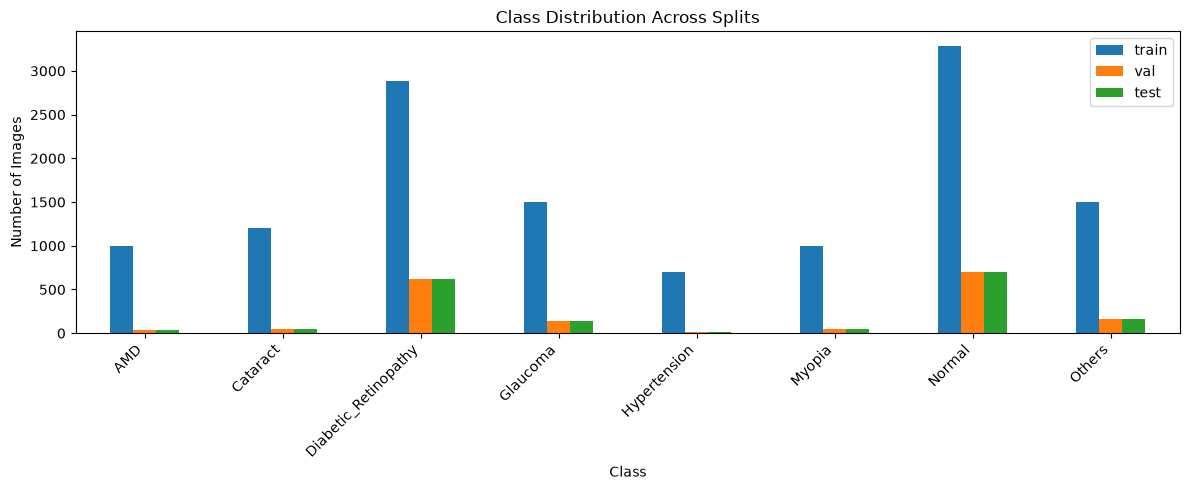

In [7]:
ax = distribution.plot(kind="bar", figsize=(12, 5))
ax.set_title("Class Distribution Across Splits")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
assert (distribution["train"] > 0).all()
assert (distribution["val"] > 0).all()
assert (distribution["test"] > 0).all()

print("Total train images:", distribution["train"].sum())
print("Total val images:  ", distribution["val"].sum())
print("Total test images: ", distribution["test"].sum())
print("Total images:      ", distribution.sum().sum())

Total train images: 13067
Total val images:   1776
Total test images:  1776
Total images:       16619
